In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, precision_recall_fscore_support,accuracy_score,confusion_matrix,classification_report
from imblearn.over_sampling import SMOTE
import joblib, os

In [2]:
os.makedirs('D:/cse/SEM5/INT234/Project/models', exist_ok=True)
os.makedirs('D:/cse/SEM5/INT234/Project/results', exist_ok=True)

In [3]:
df = pd.read_csv('D:/cse/SEM5/INT234/Project/model_ready.csv')
X = df.drop(columns=['is_productive','is_healthy'], errors='ignore')
y = df['is_productive']

In [4]:
X_train, X_val, y_train, y_val = train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)

In [5]:
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train, y_train)

In [6]:
xgb = XGBClassifier(n_estimators=400, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_res, y_res)

C:\Users\LENOVO\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [20:18:25] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=400, n_jobs=None,
              num_parallel_tree=None, ...)

In [7]:
probs = xgb.predict_proba(X_val)[:,1]
preds = (probs >= 0.5).astype(int)

In [8]:
auc = roc_auc_score(y_val, probs)
prec, rec, f1, _ = precision_recall_fscore_support(y_val, preds, average='binary')
metrics = {'model':'XGB_SMOTE','auc':auc,'precision':prec,'recall':rec,'f1':f1}


Model: XGBoost
Accuracy: 0.8751666666666666
              precision    recall  f1-score   support

           0       0.92      0.93      0.93      5041
           1       0.62      0.57      0.59       959

    accuracy                           0.88      6000
   macro avg       0.77      0.75      0.76      6000
weighted avg       0.87      0.88      0.87      6000



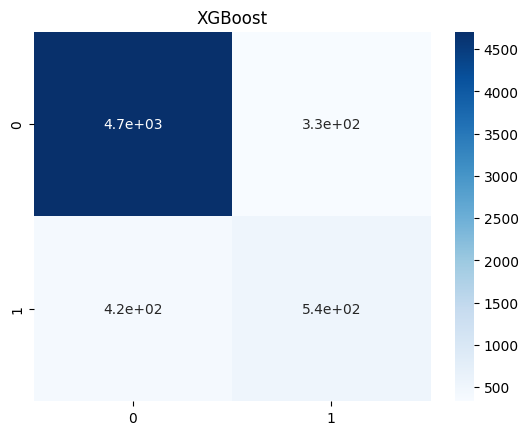

In [9]:
print(f"\nModel: XGBoost")
print("Accuracy:", accuracy_score(y_val,preds))
print(classification_report(y_val, preds))
sns.heatmap(confusion_matrix(y_val,preds), annot=True, cmap="Blues")
plt.title("XGBoost")
plt.show()

In [10]:
joblib.dump(xgb, 'D:/cse/SEM5/INT234/Project/models/xgb_smote.pkl')

['D:/cse/SEM5/INT234/Project/models/xgb_smote.pkl']

In [11]:
pd.DataFrame([metrics]).to_csv('D:/cse/SEM5/INT234/Project/results/model_metrics.csv', mode='a', header=not os.path.exists('D:/cse/SEM5/INT234/Project/results/model_metrics.csv'), index=False)